# Italian Financial Challenge - Starter Template

**Student Name:** [Your Name]

**Challenge:** [Choose: Bankruptcy Prediction / Financial Health Classification / Revenue Forecasting]

**Date:** [Date]

---

## Instructions

This template provides a suggested structure for your challenge solution. You can adapt it to your needs, but make sure to cover all required sections:

1. Problem Statement and Objectives
2. Data Loading and Exploration
3. Data Preprocessing
4. Feature Engineering
5. Model Development
6. Model Evaluation
7. Interpretation and Business Insights
8. Conclusions and Future Work

**Remember:**
- Document your thought process with markdown cells
- Comment your code clearly
- Create visualizations to support your insights
- Interpret results in business terms
- Check the evaluation rubric to ensure you meet all criteria

## 1. Problem Statement and Objectives

**Challenge:** [Describe which challenge you chose and why]

**Objective:** [State the prediction goal clearly]

**Success Criteria:** [Define what "good" performance looks like for your chosen challenge]

**Approach:** [Briefly outline your planned approach]

In [50]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Data Loading and Exploration

Load the training data and perform initial exploration.

In [51]:
# Load training data
train_df = pd.read_csv('../data/processed/train_data.csv')

print(f"Dataset shape: {train_df.shape}")
print(f"\nColumns: {train_df.columns.tolist()}")
print(f"\nFirst few rows:")
train_df.head()

Dataset shape: (11828, 30)

Columns: ['company_id', 'fiscal_year', 'province', 'region', 'ateco_sector', 'legal_form', 'years_in_business', 'total_fixed_assets', 'current_assets', 'total_assets', 'shareholders_equity', 'total_debt', 'short_term_debt', 'long_term_debt', 'production_value', 'production_costs', 'operating_income', 'financial_income', 'financial_expenses', 'net_profit_loss', 'roe', 'roi', 'leverage', 'current_ratio', 'quick_ratio', 'debt_to_assets', 'profit_margin', 'bankruptcy_next_year', 'financial_health_class', 'revenue_change']

First few rows:


,company_id,fiscal_year,province,region,ateco_sector,legal_form,years_in_business,total_fixed_assets,current_assets,total_assets,shareholders_equity,total_debt,short_term_debt,long_term_debt,production_value,production_costs,operating_income,financial_income,financial_expenses,net_profit_loss,roe,roi,leverage,current_ratio,quick_ratio,debt_to_assets,profit_margin,bankruptcy_next_year,financial_health_class,revenue_change
0,COMP_00000,2018,NaN,Campania,47,SRL,32,2.422343e+08,9.504819e+08,1.192716e+09,3.728702e+08,8.198459e+08,5.601842e+08,2.596617e+08,1.846636e+09,1.611363e+09,2.352729e+08,4886785.12,20068071.29,2.152049e+08,0.5772,0.1973,2.1987,1.6967,1.0180,0.6874,0.1165,0,B,NaN
1,COMP_00000,2019,NaN,Campania,47,SRL,33,3.983639e+07,1.411226e+08,1.809589e+08,5.700701e+07,1.239519e+08,7.135345e+07,5.259848e+07,4.289159e+08,3.896038e+08,3.931218e+07,58246.06,2537224.20,3.677495e+07,0.6451,0.2172,2.1743,1.9778,1.1867,0.6850,0.0857,0,B,-76.77
2,COMP_00000,2020,NaN,Campania,47,SRL,34,6.662250e+08,1.367208e+09,2.033433e+09,3.029046e+08,1.730529e+09,9.904004e+08,7.401282e+08,6.956197e+09,6.988489e+09,-3.229208e+07,5327332.51,55844558.38,-8.813664e+07,-0.2910,-0.0159,5.7131,1.3805,0.8283,0.8510,-0.0127,0,D,1521.81
3,COMP_00000,2021,NaN,Campania,47,SRL,35,4.637187e+07,2.524228e+08,2.987947e+08,3.901098e+07,2.597837e+08,1.527674e+08,1.070163e+08,5.031839e+08,5.047235e+08,-1.539645e+06,116335.80,7828741.61,-9.368387e+06,-0.2401,-0.0052,6.6592,1.6523,0.9914,0.8694,-0.0186,0,D,-92.77
4,COMP_00001,2018,CA,Sardegna,62,SRL,8,8.348035e+07,1.325697e+08,2.160500e+08,6.566937e+07,1.503807e+08,7.582482e+07,7.455584e+07,4.113380e+08,3.912414e+08,2.009667e+07,640538.94,5860639.22,1.423603e+07,0.2168,0.0930,2.2900,1.7484,1.0490,0.6960,0.0346,0,B,NaN


In [52]:
# Basic information
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11828 entries, 0 to 11827
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   company_id              11828 non-null  str    
 1   fiscal_year             11828 non-null  int64  
 2   province                10909 non-null  str    
 3   region                  11828 non-null  str    
 4   ateco_sector            11828 non-null  int64  
 5   legal_form              11828 non-null  str    
 6   years_in_business       11828 non-null  int64  
 7   total_fixed_assets      11828 non-null  float64
 8   current_assets          11828 non-null  float64
 9   total_assets            11828 non-null  float64
 10  shareholders_equity     11828 non-null  float64
 11  total_debt              11828 non-null  float64
 12  short_term_debt         11828 non-null  float64
 13  long_term_debt          11828 non-null  float64
 14  production_value        11828 non-null  float64
 

In [53]:
# Summary statistics
train_df.describe()

,fiscal_year,ateco_sector,years_in_business,total_fixed_assets,current_assets,total_assets,shareholders_equity,total_debt,short_term_debt,long_term_debt,production_value,production_costs,operating_income,financial_income,financial_expenses,net_profit_loss,roe,roi,leverage,current_ratio,quick_ratio,debt_to_assets,profit_margin,bankruptcy_next_year,revenue_change
count,11828.000000,11828.000000,11828.000000,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,11783.000000,11828.000000,11783.000000,11828.000000,11828.000000,11828.000000,11828.000000,11828.000000,8829.000000
mean,2019.495350,45.827697,35.179405,1.029206e+09,1.438435e+09,2.467641e+09,9.163141e+08,1.551327e+09,8.534656e+08,6.978617e+08,3.969063e+09,3.680129e+09,2.889337e+08,6.418314e+06,5.464980e+07,2.342839e+08,0.254267,0.123253,2.135329,1.869953,1.121972,0.633231,0.058008,0.007102,453.434570
std,1.116482,16.677183,19.908095,6.120958e+09,6.873106e+09,1.248305e+10,5.023564e+09,7.724478e+09,4.360360e+09,3.493369e+09,1.896096e+10,1.757911e+10,1.574126e+09,3.930832e+07,2.850800e+08,1.348222e+09,0.577374,0.091036,2.159040,0.614015,0.368409,0.114868,0.039245,0.083976,4601.920625
min,2018.000000,10.000000,0.000000,1.267167e+06,1.278800e+06,2.545968e+06,-3.330561e+09,1.839791e+06,8.985461e+05,9.412449e+05,2.329670e+06,1.580518e+06,-2.688184e+09,6.241000e+01,5.926949e+04,-4.062689e+09,-39.177100,-0.475300,0.818200,0.551000,0.330600,0.450000,-0.149700,0.000000,-99.940000
25%,2018.000000,41.000000,18.000000,7.319803e+07,1.244471e+08,2.087793e+08,7.070428e+07,1.294646e+08,6.925617e+07,5.666362e+07,2.984883e+08,2.731290e+08,1.698626e+07,3.569547e+05,4.355200e+06,1.049173e+07,0.110350,0.061900,1.165650,1.430800,0.858500,0.538500,0.030500,0.000000,-68.590000
50%,2019.000000,46.000000,35.000000,1.905995e+08,3.125597e+08,5.212379e+08,1.815958e+08,3.264152e+08,1.744802e+08,1.462585e+08,8.040019e+08,7.459428e+08,5.128590e+07,1.068330e+06,1.110262e+07,3.798727e+07,0.221600,0.105000,1.680300,1.811750,1.087050,0.627500,0.060300,0.000000,3.040000
75%,2020.000000,56.000000,52.000000,5.398741e+08,8.387197e+08,1.394478e+09,5.022747e+08,8.795087e+08,4.777298e+08,3.960070e+08,2.241163e+09,2.075266e+09,1.538062e+08,3.178533e+06,3.005698e+07,1.226862e+08,0.390750,0.170900,2.484850,2.238925,1.343325,0.713800,0.090000,0.000000,238.850000
max,2021.000000,82.000000,71.000000,2.548712e+11,2.512549e+11,5.061262e+11,1.956145e+11,3.105116e+11,1.699685e+11,1.405431e+11,6.044366e+11,5.736470e+11,5.621927e+10,1.640114e+09,9.311030e+09,5.011818e+10,1.771600,0.490600,101.153800,4.539300,2.723600,1.192300,0.120000,1.000000,302126.480000


In [54]:
# Check for missing values
missing_values = train_df.isnull().sum()
missing_pct = (missing_values / len(train_df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Percentage': missing_pct
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

print("Missing Values:")
print(missing_df)

Missing Values:
                Missing Count  Percentage
revenue_change           2999   25.355090
province                  919    7.769699
roe                        45    0.380453
leverage                   45    0.380453


In [55]:
# Target variable analysis
# TODO: Uncomment the relevant section for your challenge

# For Challenge 3: Revenue Forecasting
print("\nRevenue Change Statistics:")
print(train_df['revenue_change'].describe())
print(f"\nMissing revenue_change: {train_df['revenue_change'].isnull().sum()}")


Revenue Change Statistics:
count      8829.000000
mean        453.434570
std        4601.920625
min         -99.940000
25%         -68.590000
50%           3.040000
75%         238.850000
max      302126.480000
Name: revenue_change, dtype: float64

Missing revenue_change: 2999


### Exploratory Data Analysis (EDA)

Create visualizations to understand the data better.

In [56]:
eda_df = train_df.copy()
eda_df = eda_df.sort_values(['company_id', 'fiscal_year'])

# create next year revenue change
eda_df['revenue_change_next'] = (
    eda_df.groupby('company_id')['revenue_change'].shift(-1)
)
eda_df['production_value_next'] = (
    eda_df.groupby('company_id')['production_value'].shift(-1)
)
# Keep only rows that have a next-year value
eda_df = eda_df.dropna(subset=['production_value_next'])
# Keep only the feature years we are analyzing
eda_df = eda_df[eda_df['fiscal_year'].isin([2018, 2019])]
eda_df['cost_intensity'] = eda_df['production_costs'] / eda_df['production_value']
eda_df['asset_turnover'] = eda_df['production_value'] / eda_df['total_assets']
eda_df['debt_burden'] = eda_df['financial_expenses'] / eda_df['production_value']
eda_df['equity_ratio'] = eda_df['shareholders_equity'] / eda_df['total_assets']

In [57]:
eda_df = eda_df[eda_df['fiscal_year'].isin([2018, 2019])]

In [58]:
eda_df = eda_df.dropna(subset=['revenue_change_next'])

In [59]:
print("EDA dataset shape:", eda_df.shape)

print("\nFeature years:")
print(eda_df['fiscal_year'].value_counts())

print("\nTarget summary:")
print(eda_df['revenue_change_next'].describe())

EDA dataset shape: (5897, 36)

Feature years:
fiscal_year
2019    2956
2018    2941
Name: count, dtype: int64

Target summary:
count      5897.000000
mean        435.849856
std        3474.444067
min         -99.940000
25%         -69.200000
50%           1.100000
75%         238.190000
max      213030.290000
Name: revenue_change_next, dtype: float64


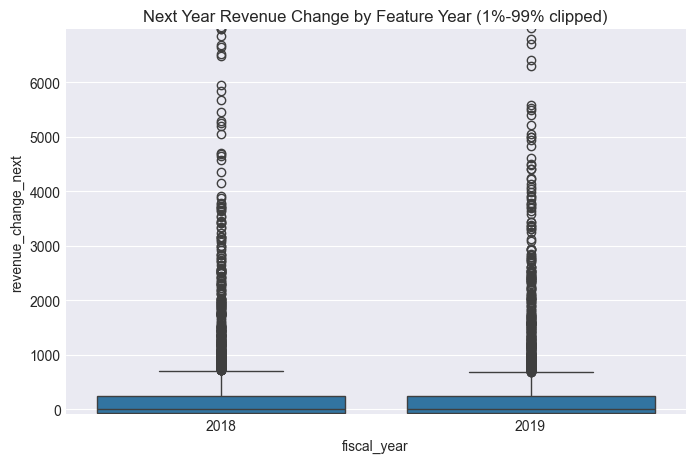

In [60]:
lower = eda_df['revenue_change_next'].quantile(0.01)
upper = eda_df['revenue_change_next'].quantile(0.99)

plt.figure(figsize=(8,5))
sns.boxplot(x='fiscal_year', y='revenue_change_next', data=eda_df)

plt.ylim(lower, upper)

plt.title("Next Year Revenue Change by Feature Year (1%-99% clipped)")
plt.show()

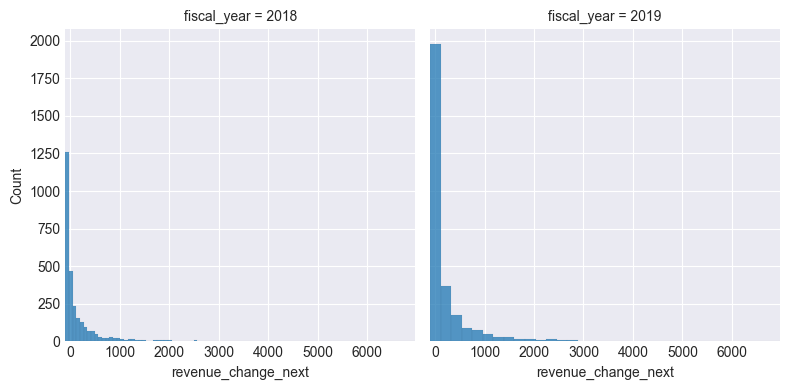

In [61]:
lower = eda_df['revenue_change_next'].quantile(0.01)
upper = eda_df['revenue_change_next'].quantile(0.99)

g = sns.FacetGrid(eda_df, col="fiscal_year", height=4)
g.map(sns.histplot, "revenue_change_next", bins=1000)

for ax in g.axes.flat:
    ax.set_xlim(lower, upper)

plt.show()

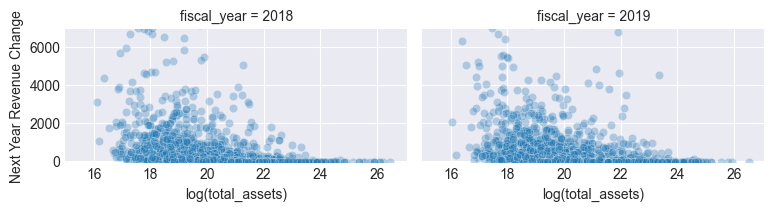

In [62]:
g = sns.FacetGrid(eda_df, col="fiscal_year", height=4)

g.map_dataframe(
    sns.scatterplot,
    x=np.log1p(eda_df['total_assets']),
    y='revenue_change_next',
    alpha=0.3
)

lower = eda_df['revenue_change_next'].quantile(0.01)
upper = eda_df['revenue_change_next'].quantile(0.99)

for ax in g.axes.flat:
    ax.set_ylim(lower, upper)

g.set_axis_labels("log(total_assets)", "Next Year Revenue Change")

plt.show()

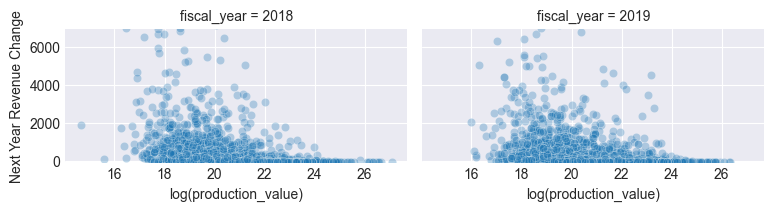

In [63]:
g = sns.FacetGrid(eda_df, col="fiscal_year", height=4)

g.map_dataframe(
    sns.scatterplot,
    x=np.log1p(eda_df['production_value']),
    y='revenue_change_next',
    alpha=0.3
)

lower = eda_df['revenue_change_next'].quantile(0.01)
upper = eda_df['revenue_change_next'].quantile(0.99)

for ax in g.axes.flat:
    ax.set_ylim(lower, upper)

g.set_axis_labels("log(production_value)", "Next Year Revenue Change")

plt.show()

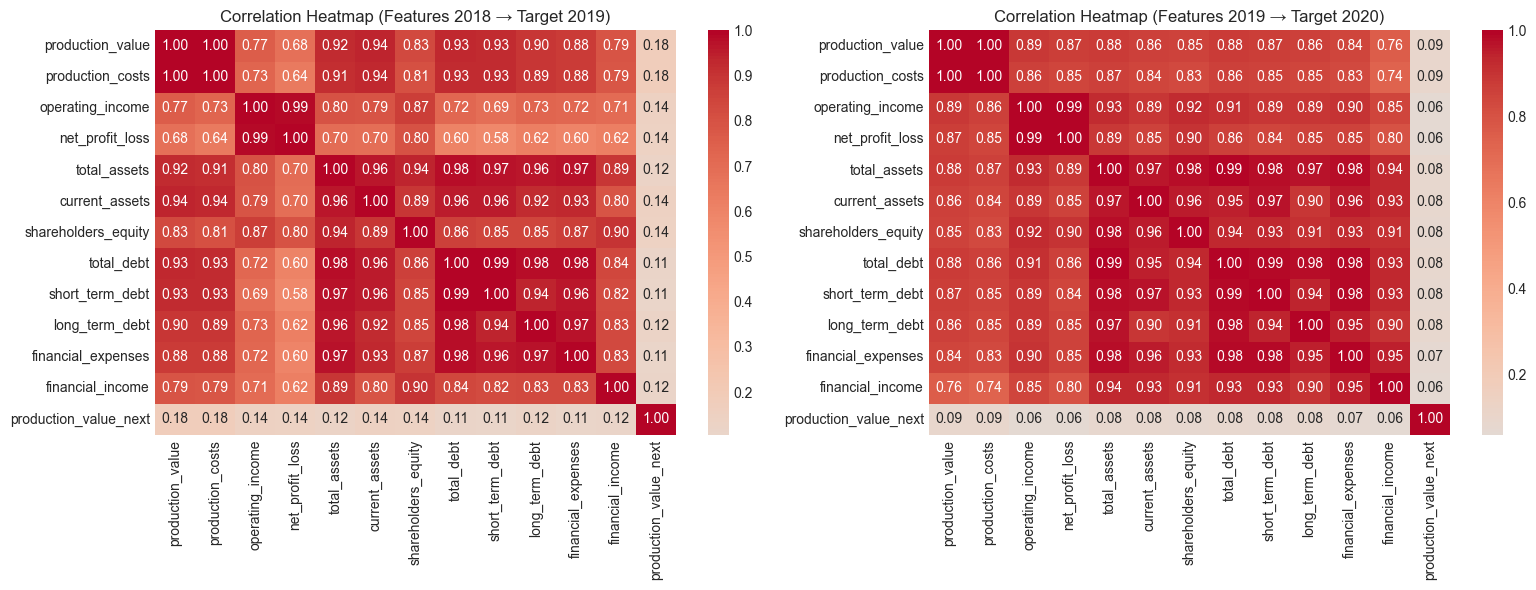

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

important_features = [
    'production_value',
    'production_costs',
    'operating_income',
    'net_profit_loss',
    'total_assets',
    'current_assets',
    'shareholders_equity',
    'total_debt',
    'short_term_debt',
    'long_term_debt',
    'financial_expenses',
    'financial_income',
    'production_value_next'
]

years = [2018, 2019]

fig, axes = plt.subplots(1, 2, figsize=(16,6))

for i, year in enumerate(years):
    
    df_year = eda_df[eda_df['fiscal_year'] == year]
    
    corr = df_year[important_features].corr()
    
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Correlation Heatmap (Features {year} → Target {year+1})")

plt.tight_layout()
plt.show()

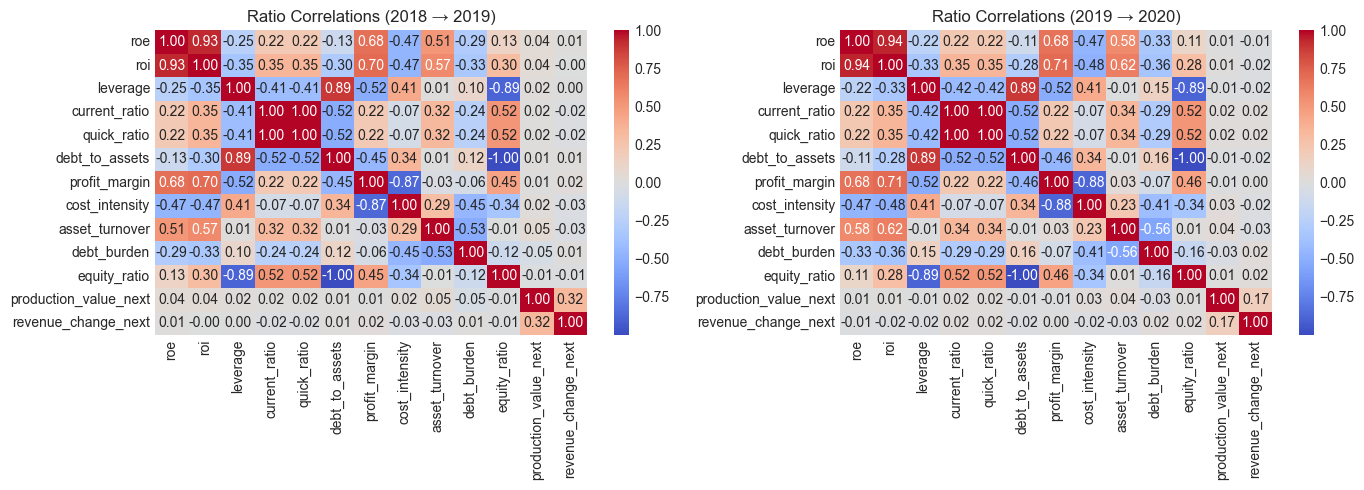

In [65]:
ratio_features = [
    'roe',
    'roi',
    'leverage',
    'current_ratio',
    'quick_ratio',
    'debt_to_assets',
    'profit_margin',
    'cost_intensity',
    'asset_turnover',
    'debt_burden',
    'equity_ratio',
    'production_value_next',
    'revenue_change_next'
]

years = [2018, 2019]

fig, axes = plt.subplots(1, 2, figsize=(14,5))

for i, year in enumerate(years):

    df_year = eda_df[eda_df['fiscal_year'] == year]

    corr = df_year[ratio_features].corr()

    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        ax=axes[i]
    )

    axes[i].set_title(f"Ratio Correlations ({year} → {year+1})")

plt.tight_layout()
plt.show()

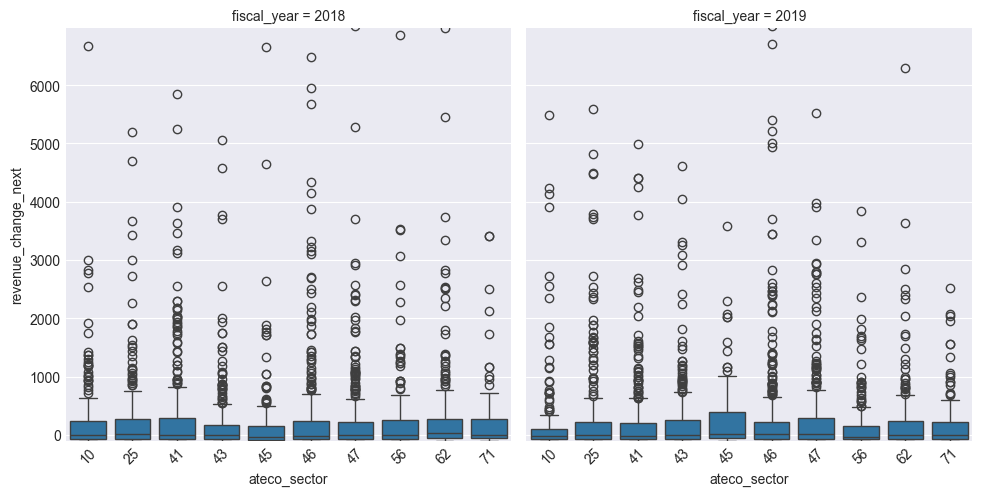

In [66]:
top_sectors = eda_df['ateco_sector'].value_counts().nlargest(10).index

g = sns.FacetGrid(
    eda_df[eda_df['ateco_sector'].isin(top_sectors)],
    col="fiscal_year",
    height=5
)

g.map_dataframe(
    sns.boxplot,
    x="ateco_sector",
    y="revenue_change_next"
)

for ax in g.axes.flat:
    ax.set_ylim(
        eda_df['revenue_change_next'].quantile(0.01),
        eda_df['revenue_change_next'].quantile(0.99)
    )
    ax.tick_params(axis='x', rotation=45)

plt.show()

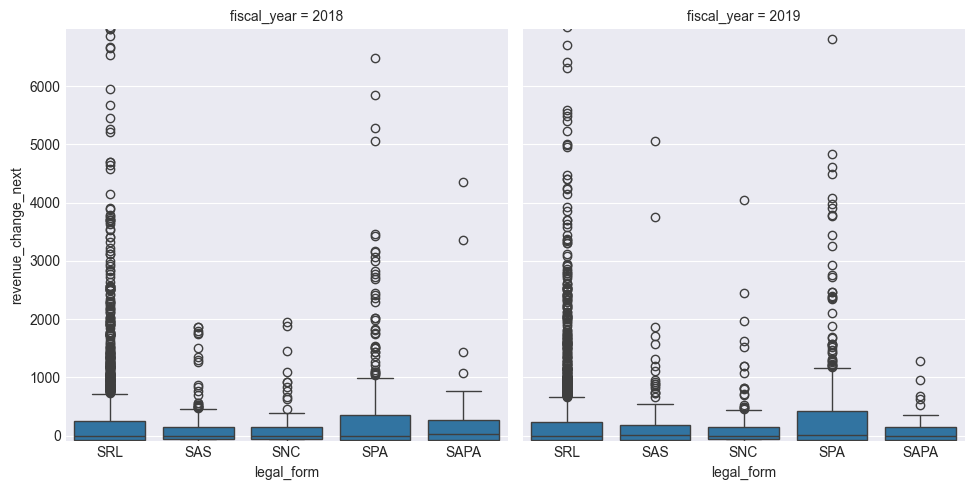

In [67]:
g = sns.FacetGrid(
    eda_df,
    col="fiscal_year",
    height=5
)

g.map_dataframe(
    sns.boxplot,
    x="legal_form",
    y="revenue_change_next"
)

for ax in g.axes.flat:
    ax.set_ylim(
        eda_df['revenue_change_next'].quantile(0.01),
        eda_df['revenue_change_next'].quantile(0.99)
    )

plt.show()

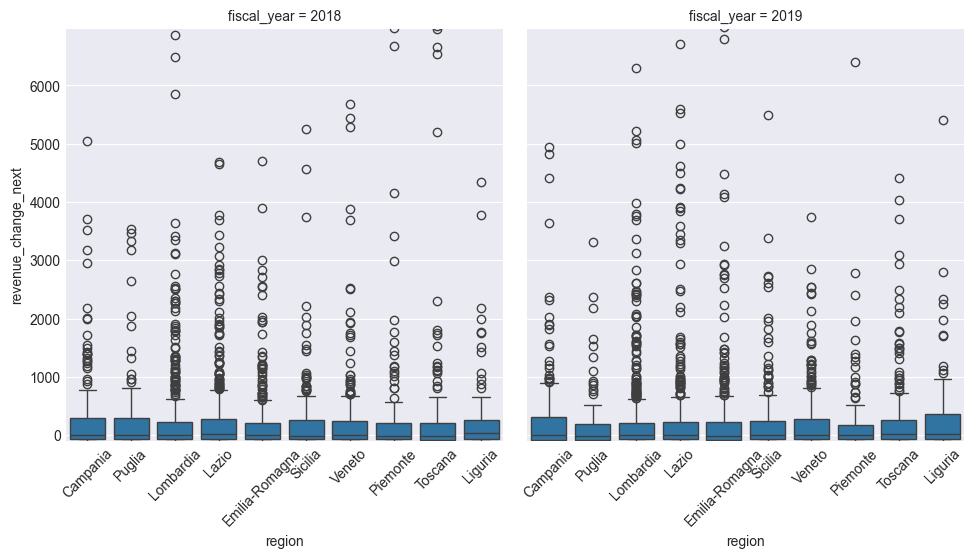

In [68]:
top_regions = eda_df['region'].value_counts().nlargest(10).index

g = sns.FacetGrid(
    eda_df[eda_df['region'].isin(top_regions)],
    col="fiscal_year",
    height=5
)

g.map_dataframe(
    sns.boxplot,
    x="region",
    y="revenue_change_next"
)

for ax in g.axes.flat:
    ax.set_ylim(
        eda_df['revenue_change_next'].quantile(0.01),
        eda_df['revenue_change_next'].quantile(0.99)
    )
    ax.tick_params(axis='x', rotation=45)

plt.show()

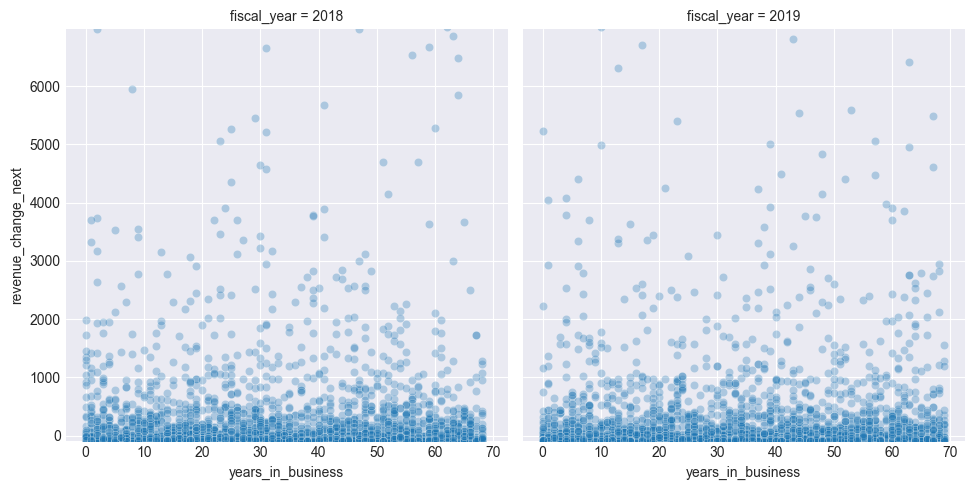

In [69]:
g = sns.FacetGrid(
    eda_df,
    col="fiscal_year",
    height=5
)

g.map_dataframe(
    sns.scatterplot,
    x="years_in_business",
    y="revenue_change_next",
    alpha=0.3
)

for ax in g.axes.flat:
    ax.set_ylim(
        eda_df['revenue_change_next'].quantile(0.01),
        eda_df['revenue_change_next'].quantile(0.99)
    )

plt.show()

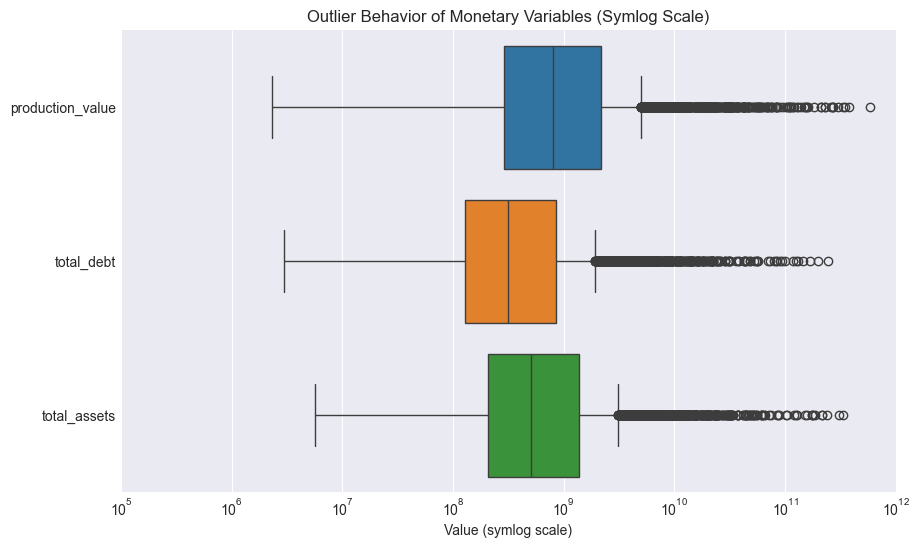

In [70]:
monetary_cols = [
    "production_value",
    "total_debt",
    "total_assets",
]
plt.figure(figsize=(10,6))

sns.boxplot(
    data=eda_df[monetary_cols],
    orient="h"
)
plt.xscale("symlog")  # handles large values + near zero values

plt.xlim(1e5, 1e12)


plt.title("Outlier Behavior of Monetary Variables (Symlog Scale)")
plt.xlabel("Value (symlog scale)")

plt.show()

In [71]:
# TODO: Create visualizations
# - Distribution plots for key financial ratios
# - Correlation heatmap
# - Target variable by sector, region, year, etc.
# - Box plots for outlier detection

**Key Insights from EDA:**

TODO: Document your key findings
- 
- 
- 

## 3. Data Preprocessing

Handle missing values, outliers, and prepare data for modeling.

In [72]:
# Load datasets
train_df = pd.read_csv('../data/processed/train_data.csv')
test_df = pd.read_csv('../data/processed/test_features.csv')

target_cols_to_drop = ['bankruptcy_next_year','financial_health_class','revenue_change']
train_df = train_df.drop(columns=target_cols_to_drop).copy()


print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain years:", sorted(train_df['fiscal_year'].unique()))
print("Test years:", sorted(test_df['fiscal_year'].unique()))

print("\nTrain columns:", len(train_df.columns))
print("Test columns:", len(test_df.columns))

Train shape: (11828, 27)
Test shape: (5811, 27)

Train years: [2018, 2019, 2020, 2021]
Test years: [2022, 2023]

Train columns: 27
Test columns: 27


In [73]:
# Create next year's production value
full_df = pd.concat([train_df, test_df], axis=0)
full_df = full_df.sort_values(['company_id', 'fiscal_year']).reset_index(drop=True)

full_df['production_value_next'] = (
    full_df.groupby('company_id')['production_value'].shift(-1)
)

print(full_df[['company_id', 'fiscal_year', 'production_value', 'production_value_next']].head(10))

   company_id  fiscal_year  production_value  production_value_next
0  COMP_00000         2018      1.846636e+09           4.289159e+08
1  COMP_00000         2019      4.289159e+08           6.956197e+09
2  COMP_00000         2020      6.956197e+09           5.031839e+08
3  COMP_00000         2021      5.031839e+08           3.898393e+08
4  COMP_00000         2022      3.898393e+08           7.742371e+09
5  COMP_00000         2023      7.742371e+09                    NaN
6  COMP_00001         2018      4.113380e+08           1.595547e+09
7  COMP_00001         2019      1.595547e+09           1.827539e+08
8  COMP_00001         2020      1.827539e+08           2.613448e+09
9  COMP_00001         2021      2.613448e+09           1.439279e+08


In [74]:
# Keep only rows where next year's production value exists
model_df = full_df.dropna(subset=['production_value_next']).copy()

print("Model dataset shape:", model_df.shape)
print("\nYears in model dataset:", sorted(model_df['fiscal_year'].unique()))

print("\nRows by year:")
print(model_df['fiscal_year'].value_counts().sort_index())

Model dataset shape: (14640, 28)

Years in model dataset: [2018, 2019, 2020, 2021, 2022]

Rows by year:
fiscal_year
2018    2941
2019    2956
2020    2932
2021    2916
2022    2895
Name: count, dtype: int64


In [75]:
# Define sliding window folds
folds = [
    {'fold_name': 'Fold 1','train_years': [2018, 2019],'val_year': 2020},
    {'fold_name': 'Fold 2','train_years': [2018, 2019, 2020],'val_year': 2021},
    {'fold_name': 'Fold 3','train_years': [2018, 2019, 2020, 2021],'val_year': 2022}
]

for fold in folds:
    print(f"{fold['fold_name']}: train = {fold['train_years']}, val = {fold['val_year']}")

Fold 1: train = [2018, 2019], val = 2020
Fold 2: train = [2018, 2019, 2020], val = 2021
Fold 3: train = [2018, 2019, 2020, 2021], val = 2022


In [76]:
# Define columns
id_cols = ['company_id', 'fiscal_year']
target_col = 'production_value_next'

feature_cols = [
    col for col in model_df.columns
    if col not in id_cols + [target_col]
]

print("Number of feature columns:", len(feature_cols))
print("\nFeature columns:")
print(feature_cols)

Number of feature columns: 25

Feature columns:
['province', 'region', 'ateco_sector', 'legal_form', 'years_in_business', 'total_fixed_assets', 'current_assets', 'total_assets', 'shareholders_equity', 'total_debt', 'short_term_debt', 'long_term_debt', 'production_value', 'production_costs', 'operating_income', 'financial_income', 'financial_expenses', 'net_profit_loss', 'roe', 'roi', 'leverage', 'current_ratio', 'quick_ratio', 'debt_to_assets', 'profit_margin']


In [77]:
def get_fold_data(model_df, feature_cols, target_col, train_years, val_year):
    train_data = model_df[model_df['fiscal_year'].isin(train_years)].copy()
    val_data = model_df[model_df['fiscal_year'] == val_year].copy()

    X_train = train_data[feature_cols].copy()
    y_train = train_data[target_col].copy()

    X_val = val_data[feature_cols].copy()
    y_val = val_data[target_col].copy()

    return train_data, val_data, X_train, y_train, X_val, y_val

In [78]:
fold_1 = folds[0]

train_data, val_data, X_train, y_train, X_val, y_val = get_fold_data(
    model_df=model_df,
    feature_cols=feature_cols,
    target_col=target_col,
    train_years=fold_1['train_years'],
    val_year=fold_1['val_year']
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

print("\nTrain years:", sorted(train_data['fiscal_year'].unique()))
print("Validation year:", val_data['fiscal_year'].unique())

Train shape: (5897, 25)
Validation shape: (2932, 25)

Train years: [2018, 2019]
Validation year: [2020]


In [79]:
def evaluate_revenue_change(y_true_prod_next, y_pred_prod_next, current_prod_value):
    # True and predicted revenue change
    y_true_rev_change = ((y_true_prod_next - current_prod_value) / current_prod_value) * 100
    y_pred_rev_change = ((y_pred_prod_next - current_prod_value) / current_prod_value) * 100

    # Metrics
    r2 = r2_score(y_true_rev_change, y_pred_rev_change)
    rmse = np.sqrt(mean_squared_error(y_true_rev_change, y_pred_rev_change))
    mae = mean_absolute_error(y_true_rev_change, y_pred_rev_change)

    # Avoid division by zero in MAPE
    mask = y_true_rev_change != 0
    mape = np.mean(
        np.abs((y_true_rev_change[mask] - y_pred_rev_change[mask]) / y_true_rev_change[mask])
    ) * 100

    return {'R2': r2,'RMSE': rmse,'MAE': mae,'MAPE': mape}

In [80]:
# ============================================================
# FEATURE ENGINEERING — Clean, leakage-safe version
# ============================================================

import numpy as np
import pandas as pd

# Sort panel data
model_df = model_df.sort_values(['company_id', 'fiscal_year']).reset_index(drop=True)

# Group by company once
grp = model_df.groupby('company_id')

def safe_div(num, den):
    den = den.replace(0, np.nan)
    return num / den

In [81]:
# Core momentum / lag features

# Previous revenue levels
model_df['production_value_lag1'] = grp['production_value'].shift(1)
model_df['production_value_lag2'] = grp['production_value'].shift(2)

# Current revenue growth computed from production_value only
model_df['revenue_change'] = safe_div(
    model_df['production_value'] - model_df['production_value_lag1'],
    model_df['production_value_lag1']
) * 100

# Revenue growth history
model_df['rev_growth_lag1'] = grp['revenue_change'].shift(1)
model_df['rev_growth_lag2'] = grp['revenue_change'].shift(2)
model_df['rev_growth_accel'] = model_df['rev_growth_lag1'] - model_df['rev_growth_lag2']
model_df['rev_growth_avg2'] = model_df[['rev_growth_lag1', 'rev_growth_lag2']].mean(axis=1)

# Simple growth regime flags
model_df['high_growth_flag'] = (model_df['revenue_change'] > 100).astype(int)
model_df['negative_growth_flag'] = (model_df['revenue_change'] < 0).astype(int)
model_df['extreme_growth_flag'] = (model_df['revenue_change'] > 200).astype(int)
model_df['extreme_decline_flag'] = (model_df['revenue_change'] < -50).astype(int)

# Lag features for important financial variables

lag_cols = [
    'production_costs',
    'operating_income',
    'net_profit_loss',
    'total_assets',
    'shareholders_equity',
    'total_debt',
    'current_assets',
    'total_fixed_assets',
    'short_term_debt',
    'long_term_debt',
    'financial_income',
    'financial_expenses'
]

for col in lag_cols:
    model_df[f'{col}_lag1'] = grp[col].shift(1)
    model_df[f'{col}_lag2'] = grp[col].shift(2)



# Year-over-year change features using lagged values only

change_cols = [
    'production_costs',
    'operating_income',
    'net_profit_loss',
    'total_assets',
    'shareholders_equity',
    'total_debt',
    'current_assets'
]

for col in change_cols:
    model_df[f'{col}_change'] = safe_div(
        model_df[f'{col}_lag1'] - model_df[f'{col}_lag2'],
        model_df[f'{col}_lag2'].abs()
    ) * 100




# Profitability / efficiency ratios

model_df['operating_margin'] = safe_div(
    model_df['operating_income'],
    model_df['production_value']
)

model_df['profit_margin_calc'] = safe_div(
    model_df['net_profit_loss'],
    model_df['production_value']
)

model_df['cost_intensity'] = safe_div(
    model_df['production_costs'],
    model_df['production_value']
)

model_df['financial_burden'] = safe_div(
    model_df['financial_expenses'],
    model_df['production_value']
)

model_df['asset_turnover'] = safe_div(
    model_df['production_value'],
    model_df['total_assets']
)

model_df['fixed_asset_turnover'] = safe_div(
    model_df['production_value'],
    model_df['total_fixed_assets']
)

model_df['capital_intensity'] = safe_div(
    model_df['total_fixed_assets'],
    model_df['production_value']
)




# Balance sheet structure / stress features

model_df['equity_ratio'] = safe_div(
    model_df['shareholders_equity'],
    model_df['total_assets']
)

model_df['debt_to_equity'] = safe_div(
    model_df['total_debt'],
    model_df['shareholders_equity']
)

model_df['debt_mix_short'] = safe_div(
    model_df['short_term_debt'],
    model_df['total_debt']
)

model_df['debt_mix_long'] = safe_div(
    model_df['long_term_debt'],
    model_df['total_debt']
)

model_df['working_capital'] = model_df['current_assets'] - model_df['short_term_debt']

model_df['working_capital_to_assets'] = safe_div(
    model_df['working_capital'],
    model_df['total_assets']
)

model_df['interest_coverage_proxy'] = safe_div(
    model_df['operating_income'],
    model_df['financial_expenses'].abs()
)

model_df['profit_to_debt'] = safe_div(
    model_df['net_profit_loss'],
    model_df['total_debt']
)

model_df['net_debt'] = model_df['total_debt'] - model_df['current_assets']



# Risk / state flags

model_df['loss_flag'] = (model_df['net_profit_loss'] < 0).astype(int)
model_df['negative_operating_income_flag'] = (model_df['operating_income'] < 0).astype(int)
model_df['negative_equity_flag'] = (model_df['shareholders_equity'] < 0).astype(int)
model_df['high_leverage_flag'] = (model_df['leverage'] > 2).astype(int)
model_df['high_cost_flag'] = (model_df['cost_intensity'] > 0.9).astype(int)

model_df['financial_stress_flag'] = (
    (model_df['loss_flag'] == 1) &
    (model_df['debt_to_assets'] > 0.7)
).astype(int)

model_df['healthy_growth_flag'] = (
    (model_df['revenue_change'] > 0) &
    (model_df['profit_margin_calc'] > 0) &
    (model_df['debt_to_assets'] < 0.5)
).astype(int)






# Log size features for highly skewed positive scale variables

log_cols = [
    'production_value',
    'production_value_lag1',
    'production_costs',
    'total_assets',
    'total_assets_lag1',
    'current_assets',
    'total_fixed_assets',
    'total_debt',
    'short_term_debt',
    'long_term_debt',
    'years_in_business'
]

for col in log_cols:
    if col in model_df.columns:
        model_df[f'log_{col}'] = np.log1p(model_df[col].clip(lower=0))





# Leakage-safe sector and region relative features
# Each year T gets sector/region statistics from year T-1 only

# ---- Sector-year stats
sector_stats = (
    model_df.groupby(['ateco_sector', 'fiscal_year'])
    .agg(
        sector_median_revenue_change=('revenue_change', 'median'),
        sector_median_profit_margin=('profit_margin_calc', 'median'),
        sector_median_asset_turnover=('asset_turnover', 'median'),
        sector_size=('company_id', 'count')
    )
    .reset_index()
)

sector_stats['fiscal_year'] = sector_stats['fiscal_year'] + 1

model_df = model_df.merge(
    sector_stats,
    on=['ateco_sector', 'fiscal_year'],
    how='left'
)

# ---- Region-year stats
region_stats = (
    model_df.groupby(['region', 'fiscal_year'])
    .agg(
        region_median_revenue_change=('revenue_change', 'median')
    )
    .reset_index()
)

region_stats['fiscal_year'] = region_stats['fiscal_year'] + 1

model_df = model_df.merge(
    region_stats,
    on=['region', 'fiscal_year'],
    how='left'
)

# ---- Relative features
model_df['revenue_change_vs_sector'] = (
    model_df['rev_growth_lag1'] - model_df['sector_median_revenue_change']
)

model_df['profit_margin_vs_sector'] = (
    model_df['profit_margin_calc'] - model_df['sector_median_profit_margin']
)

model_df['asset_turnover_vs_sector'] = (
    model_df['asset_turnover'] - model_df['sector_median_asset_turnover']
)

model_df['revenue_change_vs_region'] = (
    model_df['rev_growth_lag1'] - model_df['region_median_revenue_change']
)





# COVID / regime features

model_df['covid_dummy'] = model_df['fiscal_year'].isin([2020, 2021]).astype(int)
model_df['post_covid_dummy'] = (model_df['fiscal_year'] >= 2022).astype(int)

# Sector COVID impact measured from 2020 only, then merged by sector
sector_covid_impact = (
    model_df[model_df['fiscal_year'] == 2020]
    .groupby('ateco_sector')['revenue_change']
    .median()
    .rename('sector_covid_impact')
    .reset_index()
)

model_df = model_df.merge(
    sector_covid_impact,
    on='ateco_sector',
    how='left'
)
# Ratio change features (all leakage-safe: use only t-1 and t-2)

model_df['operating_margin_lag1'] = grp['operating_margin'].shift(1)
model_df['operating_margin_lag2'] = grp['operating_margin'].shift(2)
model_df['operating_margin_change'] = (
    model_df['operating_margin_lag1'] - model_df['operating_margin_lag2']
)

model_df['asset_turnover_lag1'] = grp['asset_turnover'].shift(1)
model_df['asset_turnover_lag2'] = grp['asset_turnover'].shift(2)
model_df['asset_turnover_change'] = (
    model_df['asset_turnover_lag1'] - model_df['asset_turnover_lag2']
)

model_df['debt_to_assets_lag1'] = grp['debt_to_assets'].shift(1)
model_df['debt_to_assets_lag2'] = grp['debt_to_assets'].shift(2)
model_df['debt_to_assets_change'] = (
    model_df['debt_to_assets_lag1'] - model_df['debt_to_assets_lag2']
)

model_df['leverage_lag1'] = grp['leverage'].shift(1)
model_df['leverage_lag2'] = grp['leverage'].shift(2)
model_df['leverage_change'] = (
    model_df['leverage_lag1'] - model_df['leverage_lag2']
)

model_df['current_ratio_lag1'] = grp['current_ratio'].shift(1)
model_df['current_ratio_lag2'] = grp['current_ratio'].shift(2)
model_df['current_ratio_change'] = (
    model_df['current_ratio_lag1'] - model_df['current_ratio_lag2']
)

model_df['financial_burden_lag1'] = grp['financial_burden'].shift(1)
model_df['financial_burden_lag2'] = grp['financial_burden'].shift(2)
model_df['financial_burden_change'] = (
    model_df['financial_burden_lag1'] - model_df['financial_burden_lag2']
)


# Replace inf values with NaN
model_df = model_df.replace([np.inf, -np.inf], np.nan)

print("Feature engineering complete.")
print("Current shape:", model_df.shape)




# Rebuild feature lists after feature engineering

id_cols = ['company_id', 'fiscal_year']
target_col = 'production_value_next'

feature_cols = [
    col for col in model_df.columns
    if col not in id_cols + [target_col]
]

categorical_cols = ['ateco_sector', 'region', 'province', 'legal_form']
categorical_cols = [col for col in categorical_cols if col in feature_cols]

numeric_cols = [col for col in feature_cols if col not in categorical_cols]

print("Total features:", len(feature_cols))
print("Categorical features:", categorical_cols)
print("Numeric feature count:", len(numeric_cols))

Feature engineering complete.
Current shape: (14640, 134)
Total features: 131
Categorical features: ['ateco_sector', 'region', 'province', 'legal_form']
Numeric feature count: 127


In [98]:
print("production_value_next in feature_cols?", 'production_value_next' in feature_cols)
print("company_id in feature_cols?", 'company_id' in feature_cols)
print("fiscal_year in feature_cols?", 'fiscal_year' in feature_cols)

production_value_next in feature_cols? False
company_id in feature_cols? False
fiscal_year in feature_cols? False


In [82]:
# Create a copy for preprocessing
df_processed = train_df.copy()

# TODO: Handle missing values
# - Decide on imputation strategy (median, mean, by group, etc.)
# - Document your rationale

# TODO: Handle outliers
# - Identify outliers (IQR, winsorization, etc.)
# - Decide on treatment strategy

# TODO: Encode categorical variables
# - One-hot encoding, label encoding, etc.

print("Preprocessing complete!")

Preprocessing complete!


In [83]:
# Feature scaling
# IMPORTANT: Fit scaler on training data only!

from sklearn.preprocessing import StandardScaler, RobustScaler

# TODO: Choose and apply scaler
# scaler = StandardScaler()  # or RobustScaler() for outlier resistance
# X_train_scaled = scaler.fit_transform(X_train)
# X_val_scaled = scaler.transform(X_val)

print("Feature scaling complete!")

Feature scaling complete!


## 4. Feature Engineering

Create new features based on domain knowledge.

In [84]:
# TODO: Engineer features
# Ideas:
# - Financial ratios (if not already present)
# - Year-over-year changes (growth rates)
# - Interaction features
# - Altman Z-Score or similar bankruptcy models
# - Sector-relative features (company vs sector average)
# - Temporal features (trends, volatility)

# Example: Year-over-year change
# df_processed = df_processed.sort_values(['company_id', 'fiscal_year'])
# df_processed['roe_yoy_change'] = df_processed.groupby('company_id')['roe'].diff()

print("Feature engineering complete!")
print(f"Total features: {df_processed.shape[1]}")

Feature engineering complete!
Total features: 27


In [85]:
# Basic impossible value checks
checks = {
    'negative_production_value': (model_df['production_value'] < 0).sum(),
    'negative_total_assets': (model_df['total_assets'] < 0).sum(),
    'negative_current_assets': (model_df['current_assets'] < 0).sum(),
    'negative_total_fixed_assets': (model_df['total_fixed_assets'] < 0).sum(),
    'negative_total_debt': (model_df['total_debt'] < 0).sum(),
}

print("Impossible / suspicious value checks:")
for k, v in checks.items():
    print(f"{k}: {v}")

Impossible / suspicious value checks:
negative_production_value: 0
negative_total_assets: 0
negative_current_assets: 0
negative_total_fixed_assets: 0
negative_total_debt: 0


In [86]:
# Accounting identity check: total_assets ≈ shareholders_equity + total_debt
model_df['accounting_gap'] = model_df['total_assets'] - (
    model_df['shareholders_equity'] + model_df['total_debt']
)

model_df['accounting_gap_pct_assets'] = (
    model_df['accounting_gap'] / model_df['total_assets'].replace(0, np.nan)
) * 100

print("Accounting gap summary:")
print(model_df['accounting_gap'].describe())

print("\nAccounting gap as % of assets summary:")
print(model_df['accounting_gap_pct_assets'].describe())

Accounting gap summary:
count    14640.000000
mean        -0.000005
std          0.005000
min         -0.010010
25%          0.000000
50%          0.000000
75%          0.000000
max          0.010010
Name: accounting_gap, dtype: float64

Accounting gap as % of assets summary:
count    1.464000e+04
mean     4.994692e-11
std      5.498780e-09
min     -1.078798e-07
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.927779e-07
Name: accounting_gap_pct_assets, dtype: float64


In [87]:
# Ratio verification checks
model_df['debt_to_assets_recalc'] = model_df['total_debt'] / model_df['total_assets'].replace(0, np.nan)
model_df['profit_margin_recalc'] = model_df['net_profit_loss'] / model_df['production_value'].replace(0, np.nan)
model_df['roe_recalc'] = model_df['net_profit_loss'] / model_df['shareholders_equity'].replace(0, np.nan)

print("Debt-to-assets difference:")
print((model_df['debt_to_assets'] - model_df['debt_to_assets_recalc']).describe())

print("\nProfit margin difference:")
print((model_df['profit_margin'] - model_df['profit_margin_recalc']).describe())

print("\nROE difference:")
print((model_df['roe'] - model_df['roe_recalc']).describe())

Debt-to-assets difference:
count    1.464000e+04
mean     2.923316e-07
std      2.907449e-05
min     -4.999267e-05
25%     -2.492329e-05
50%      3.491462e-07
75%      2.582301e-05
max      4.999921e-05
dtype: float64

Profit margin difference:
count    1.464000e+04
mean     1.966679e-07
std      2.894979e-05
min     -4.999153e-05
25%     -2.513318e-05
50%      4.816087e-08
75%      2.550257e-05
max      4.999306e-05
dtype: float64

ROE difference:
count    1.464000e+04
mean    -1.560391e-07
std      2.887166e-05
min     -4.998945e-05
25%     -2.496274e-05
50%     -1.689540e-07
75%      2.488090e-05
max      4.999962e-05
dtype: float64


**Engineered Features:**

TODO: List and explain your engineered features
1. 
2. 
3. 

## 5. Model Development

Train multiple models and compare performance.

In [88]:
# Import models
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    f1_score, roc_auc_score, accuracy_score,
    mean_squared_error, mean_absolute_error, r2_score
)
from xgboost import XGBClassifier, XGBRegressor

# For handling class imbalance (Challenges 1 & 2)
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight

print("Model libraries imported!")

Model libraries imported!


In [89]:
# TODO: Prepare X and y
# feature_cols = [...]  # List your feature columns
# target_col = 'bankruptcy_next_year'  # or 'financial_health_class' or 'revenue_change'

# X_train = df_train[feature_cols]
# y_train = df_train[target_col]
# X_val = df_val[feature_cols]
# y_val = df_val[target_col]

print("Data prepared for modeling!")

Data prepared for modeling!


### Baseline Model

In [90]:
# TODO: Train baseline model
# For classification: Logistic Regression
# For regression: Linear Regression

# Example for Challenge 1 (Bankruptcy):
# baseline_model = LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced')
# baseline_model.fit(X_train_scaled, y_train)
# y_pred_baseline = baseline_model.predict(X_val_scaled)

# print("Baseline Model Performance:")
# print(classification_report(y_val, y_pred_baseline))
# print(f"F1-Score: {f1_score(y_val, y_pred_baseline):.4f}")

### Advanced Models

In [91]:
# TODO: Train multiple models
# - Random Forest
# - XGBoost
# - Gradient Boosting
# - etc.

# For classification with imbalance, consider:
# - SMOTE oversampling
# - Class weights
# - Threshold tuning

# Example for Random Forest with SMOTE:
# smote = SMOTE(random_state=RANDOM_STATE)
# X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# rf_model = RandomForestClassifier(
#     n_estimators=100,
#     max_depth=10,
#     random_state=RANDOM_STATE
# )
# rf_model.fit(X_train_resampled, y_train_resampled)

print("Advanced models trained!")

Advanced models trained!


In [92]:
# TODO: Hyperparameter tuning
# Use GridSearchCV or RandomizedSearchCV

from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Example:
# param_grid = {
#     'n_estimators': [50, 100, 200],
#     'max_depth': [5, 10, 15],
#     'min_samples_split': [2, 5, 10]
# }

# grid_search = GridSearchCV(
#     RandomForestClassifier(random_state=RANDOM_STATE),
#     param_grid,
#     cv=StratifiedKFold(n_splits=5),
#     scoring='f1',
#     n_jobs=-1
# )
# grid_search.fit(X_train_scaled, y_train)
# best_model = grid_search.best_estimator_

print("Hyperparameter tuning complete!")

Hyperparameter tuning complete!


## 6. Model Evaluation

Compare models and select the best one.

In [93]:
# TODO: Create model comparison table
# Compare all models on validation set using appropriate metrics

# For Challenge 1: F1-Score, AUC-ROC, Precision, Recall
# For Challenge 2: Weighted F1, Macro F1, Accuracy, Confusion Matrix
# For Challenge 3: RMSE, MAE, MAPE, R², Directional Accuracy

# Example comparison:
# models_comparison = pd.DataFrame({
#     'Model': ['Baseline', 'Random Forest', 'XGBoost'],
#     'F1-Score': [...],
#     'AUC-ROC': [...],
#     'Precision': [...],
#     'Recall': [...]
# })
# print(models_comparison)

In [94]:
# TODO: Confusion Matrix (for classification)
# from sklearn.metrics import ConfusionMatrixDisplay

# ConfusionMatrixDisplay.from_estimator(best_model, X_val_scaled, y_val)
# plt.title('Confusion Matrix - Best Model')
# plt.show()

In [95]:
# TODO: ROC Curve (for binary classification)
# from sklearn.metrics import RocCurveDisplay

# RocCurveDisplay.from_estimator(best_model, X_val_scaled, y_val)
# plt.title('ROC Curve - Best Model')
# plt.show()

**Model Selection:**

TODO: Justify your final model choice
- 
- 

## 7. Interpretation and Business Insights

Explain the model and extract business value.

In [96]:
# TODO: Feature Importance
# For tree-based models, use built-in feature importance
# For other models, consider SHAP values

# Example:
# feature_importance = pd.DataFrame({
#     'feature': feature_cols,
#     'importance': best_model.feature_importances_
# }).sort_values('importance', ascending=False)

# plt.figure(figsize=(10, 6))
# plt.barh(feature_importance['feature'][:15], feature_importance['importance'][:15])
# plt.xlabel('Importance')
# plt.title('Top 15 Most Important Features')
# plt.gca().invert_yaxis()
# plt.tight_layout()
# plt.show()

In [97]:
# TODO: Error Analysis
# - Which cases does the model misclassify/mispredicts?
# - Are there patterns in the errors?
# - How do errors vary by sector, size, region, etc.?

# Example:
# errors_df = df_val.copy()
# errors_df['prediction'] = y_pred
# errors_df['error'] = (errors_df['prediction'] != errors_df[target_col])

# print("Error rate by sector:")
# print(errors_df.groupby('ateco_sector')['error'].mean().sort_values(ascending=False))

**Business Insights:**

TODO: Translate technical findings into business language

**Key Risk Factors** (for bankruptcy/health challenges):
1. 
2. 
3. 

**Revenue Drivers** (for forecasting challenge):
1. 
2. 
3. 

**Actionable Recommendations:**
- 
- 
- 

## 8. Conclusions and Future Work

Summarize findings and discuss limitations.

**Summary:**

TODO: Summarize your work
- 
- 

**Performance vs Targets:**

TODO: Compare your results to challenge targets
- My F1-Score: [X.XX] vs Target: [0.55-0.70]
- ...

**Model Limitations:**

TODO: Discuss limitations honestly
1. 
2. 
3. 

**Future Improvements:**

TODO: What would you do with more time?
1. 
2. 
3. 

**Lessons Learned:**

TODO: Reflect on the experience
- 
- 

---

## Final Checklist

Before submitting, verify:

- [ ] All code cells execute without errors
- [ ] Markdown cells explain each step clearly
- [ ] Visualizations are clear and labeled
- [ ] Feature importance is analyzed
- [ ] Error analysis is performed
- [ ] Business insights are provided
- [ ] Model limitations are discussed
- [ ] Code is well-commented
- [ ] Results meet or exceed minimum performance targets
- [ ] No data leakage (temporal split, proper scaling, etc.)
- [ ] Citations for any external code/resources

**Good luck with your challenge!** 🚀